# Libraries

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt  

# Load your CSV
df = pd.read_csv("/Users/mac/Downloads/Pakistan Largest Ecommerce Dataset (1) 2.csv")  

# Check first few rows
print(df.head())
print(df.columns)


# Convert date columns datetime

In [18]:
df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce')
df['Working Date'] = pd.to_datetime(df['Working Date'], errors='coerce')

# Total Revenue Over Time

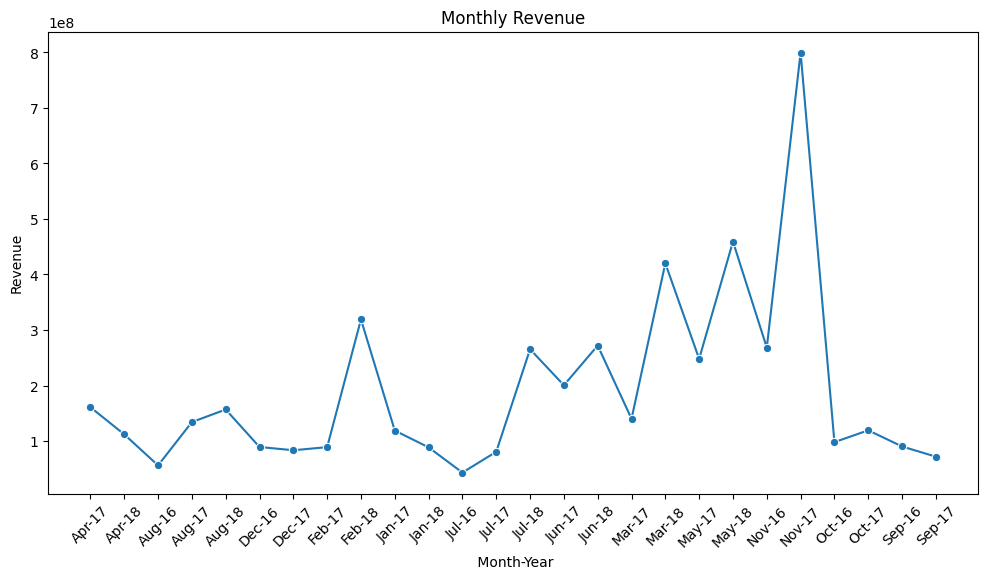

In [19]:
monthly_sales = df.groupby('M-Y') ['grand_total'].sum().reset_index()
plt.figure(figsize=(12,6))
sns.lineplot(data=monthly_sales, x='M-Y', y='grand_total', marker='o')
plt.xticks(rotation=45)
plt.title("Monthly Revenue")
plt.ylabel("Revenue")
plt.xlabel(" Month-Year")
plt.show()

# Most Popular Products ( by qty_ordered)

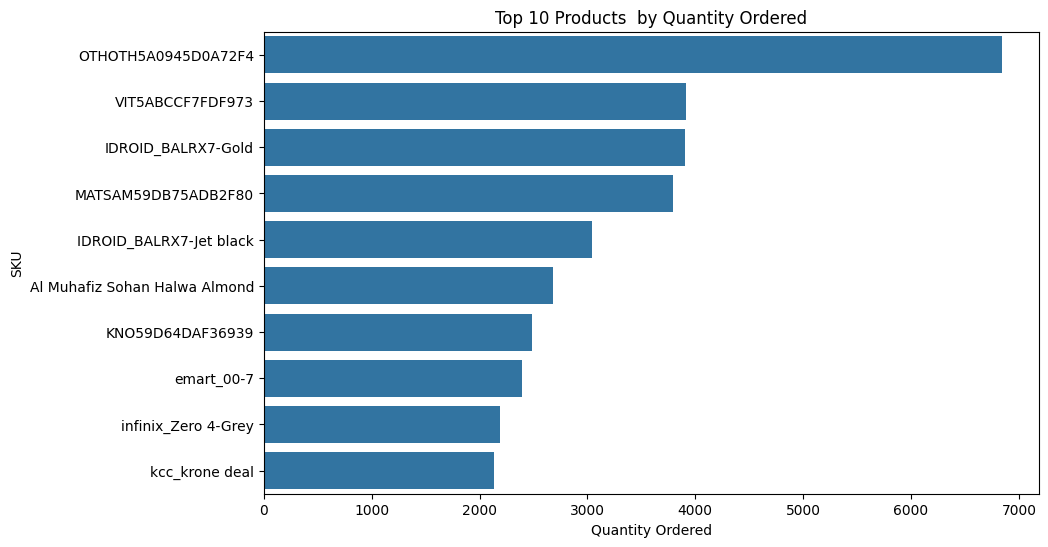

In [21]:
top_products = df.groupby('sku') ['qty_ordered'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=top_products.values, y=top_products.index)
plt.title("Top 10 Products  by Quantity Ordered")
plt.xlabel("Quantity Ordered")
plt.ylabel("SKU")
plt.show()


# most Popular Categories

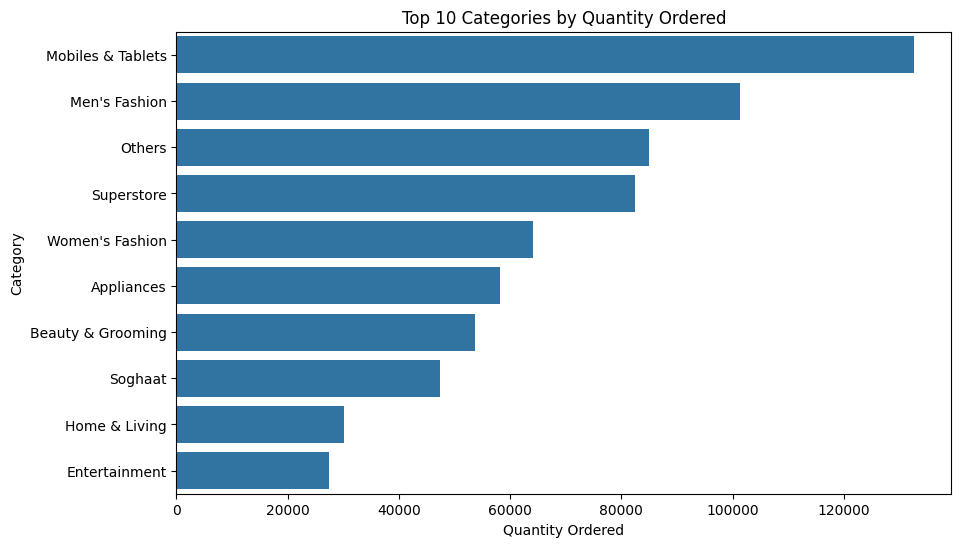

In [23]:
top_categories = df.groupby('category_name_1')['qty_ordered'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=top_categories.values, y=top_categories.index)
plt.title("Top 10 Categories by Quantity Ordered")
plt.xlabel("Quantity Ordered")
plt.ylabel("Category")
plt.show()

# Customer Analysis: New Vs Returning

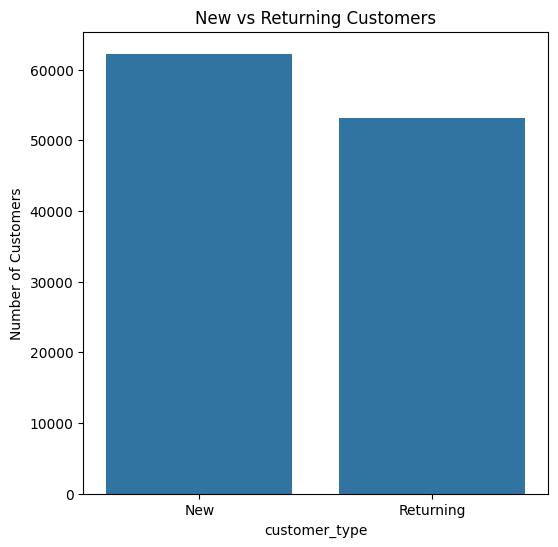

In [30]:
customer_counts = df.groupby('Customer ID')['increment_id'].nunique().reset_index()
customer_counts['customer_type'] = customer_counts['increment_id'].apply(lambda x: 'Returning' if x > 1 else 'New')
customer_type_count = customer_counts['customer_type'].value_counts()
plt.figure(figsize=(6,6))
sns.barplot(x=customer_type_count.index, y=customer_type_count.values)
plt.title("New vs Returning Customers")
plt.ylabel("Number of Customers")
plt.show()


# Payment method Analysis

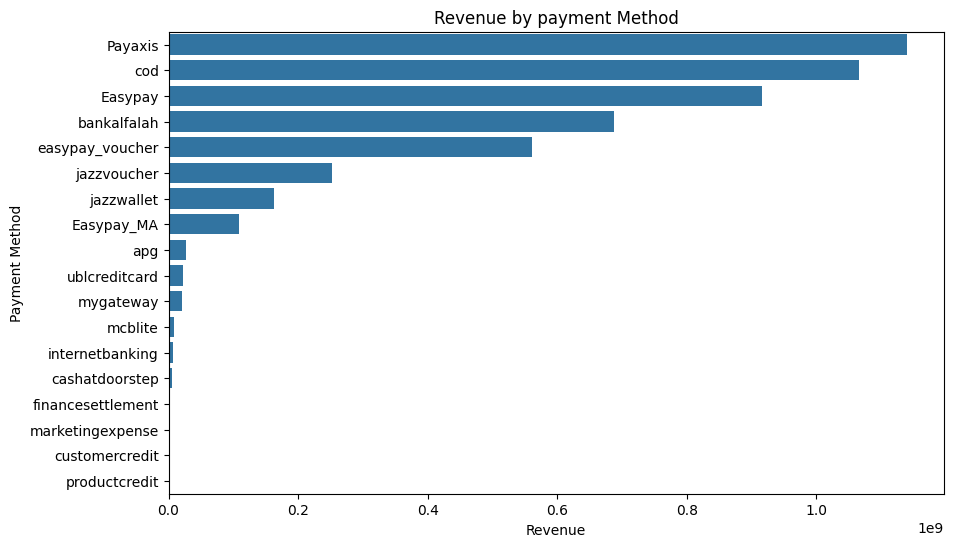

In [27]:
payment_method_count = df.groupby('payment_method') ['grand_total'].sum().sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=payment_method_count.values, y=payment_method_count.index)
plt.title("Revenue by payment Method")
plt.xlabel("Revenue")
plt.ylabel("Payment Method")
plt.show()


# Discount Analysis

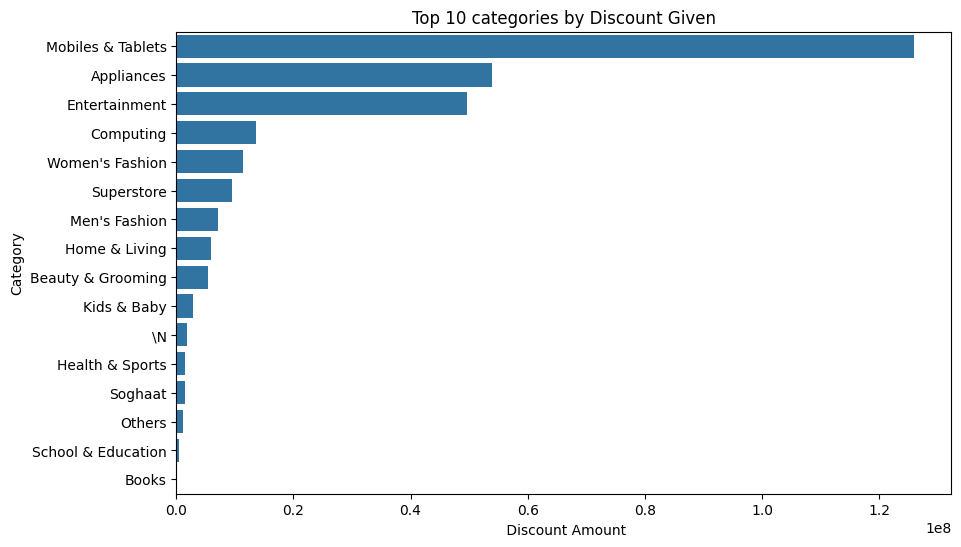

In [28]:
discount_analysis = df.groupby('category_name_1')['discount_amount'].sum().sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x= discount_analysis.values, y = discount_analysis.index)
plt.title("Top 10 categories by Discount Given")
plt.xlabel(" Discount Amount")
plt.ylabel("Category")
plt.show()